# Chapter 14. 양자 오토인코더(Quantum Autoencoder)

이 튜토리얼의 목표는 양자 오토인코더(Quantum Autoencoder)를 구축하는 것이다.

## 목차(Contents)

## 1. 오토인코더란 무엇인가?(What is an Autoencoder?)

고전 오토인코더(Classical Autoencoder, CAE)는 데이터를 압축하고 복원하는 신경망의 한 유형이다.

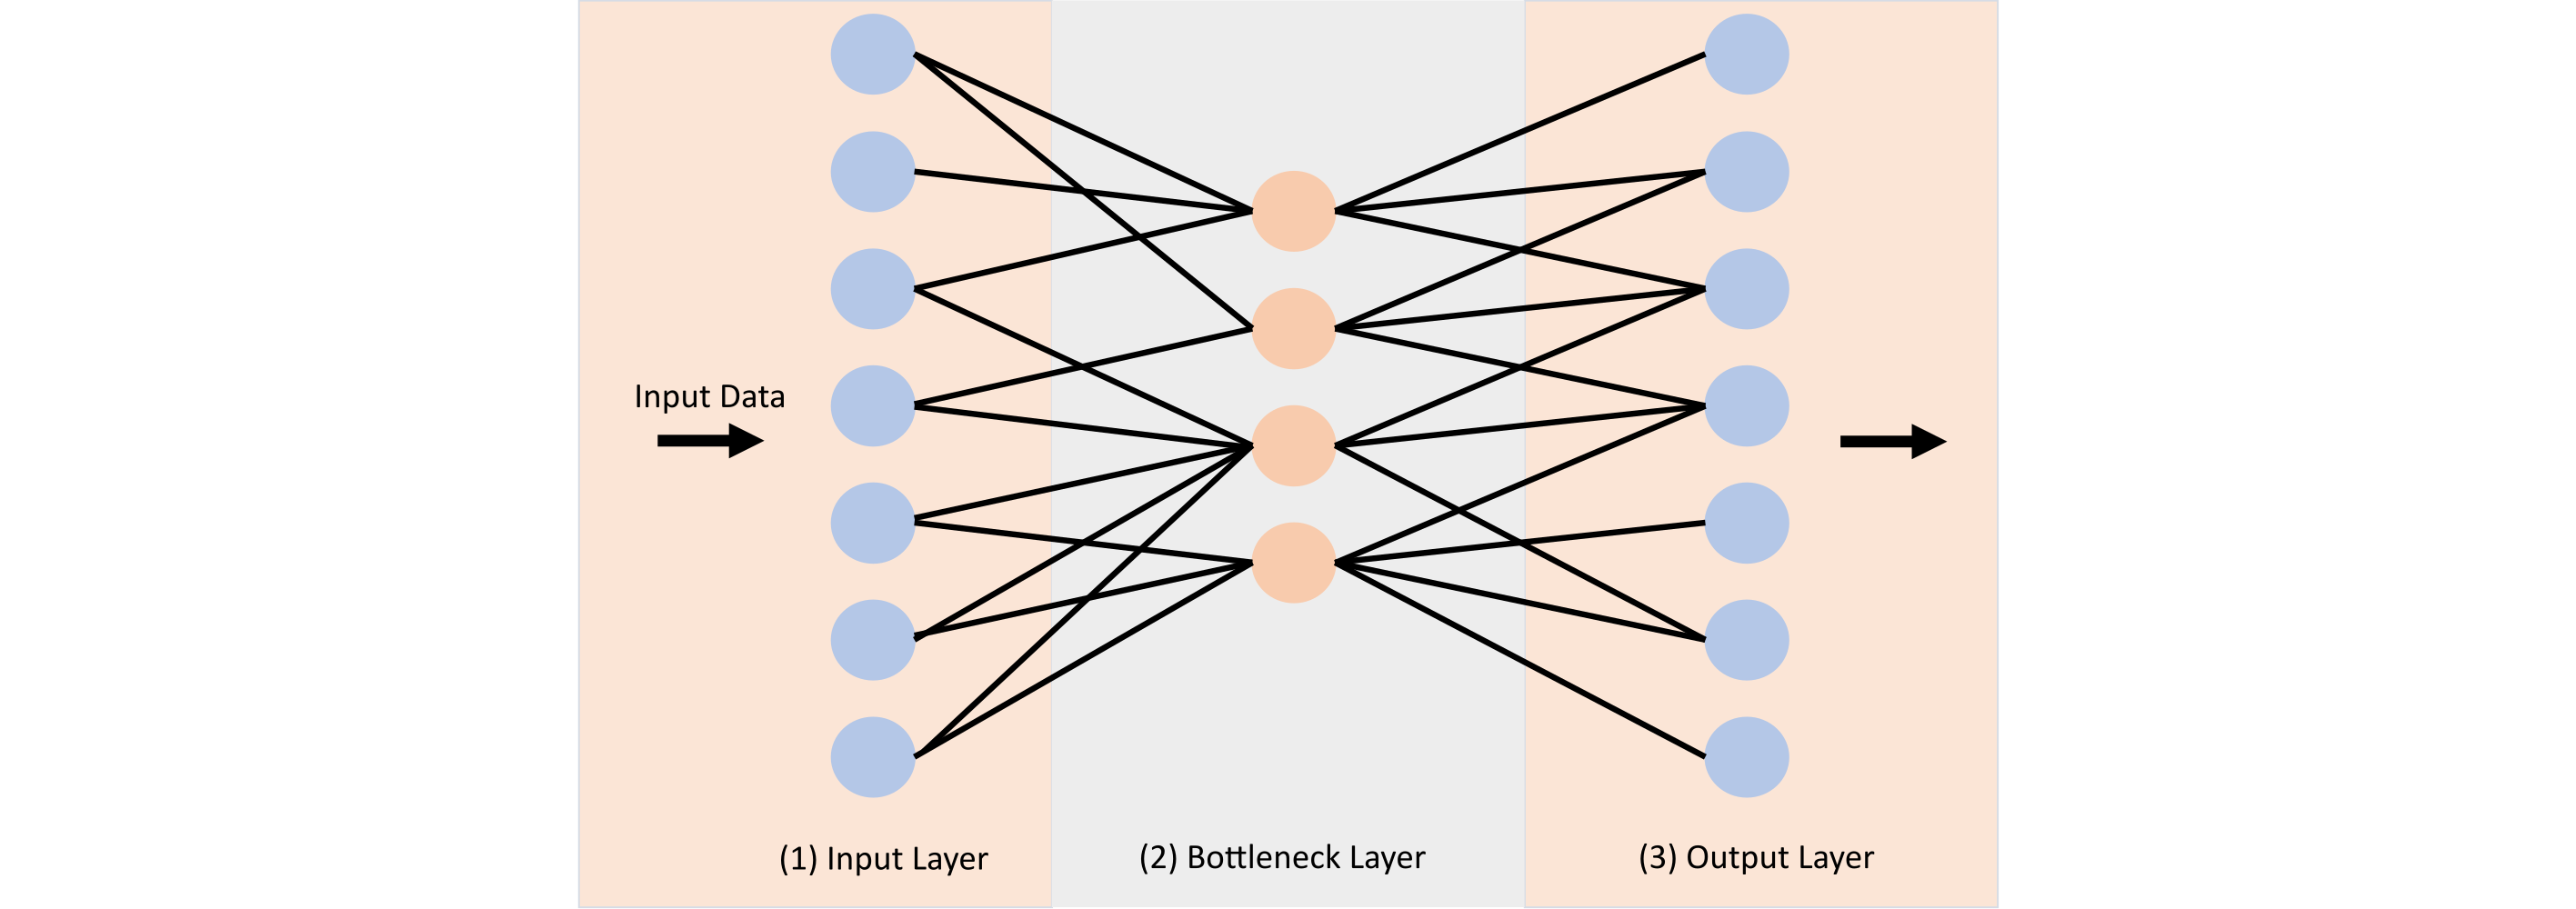

*그림 1: 입력층(Input Layer), 인코더(Encoder), 병목층(Bottleneck), 디코더(Decoder), 출력층(Output Layer)을 포함한 고전적 오토인코더(Classical Autoencoder) 구조*

첫 번째 계층을 입력 계층(Input Layer, 1)이라고 하며, 이는 원본 데이터 입력을 받는 계층이다. 두 번째 계층은 인코더(Encoder, 2)이며, 이는 입력을 낮은 차원의 표현으로 압축한다. 세 번째 계층은 병목(Bottleneck, 3)으로 알려져 있으며, 이는 낮은 차원의 압축된 데이터이다. 네 번째 계층은 디코더(Decoder, 4)이며, 이는 압축된 데이터로부터 원래 상태를 복원한다. 마지막 계층은 출력 계층(Output Layer, 5)이다.

## 2. 양자 오토인코더(The Quantum Autoencoder)

우리는 또한 고전 오토인코더(CAE)의 양자 대응물인 양자 오토인코더(Quantum Autoencoder, QAE)를 정의할 수 있다.

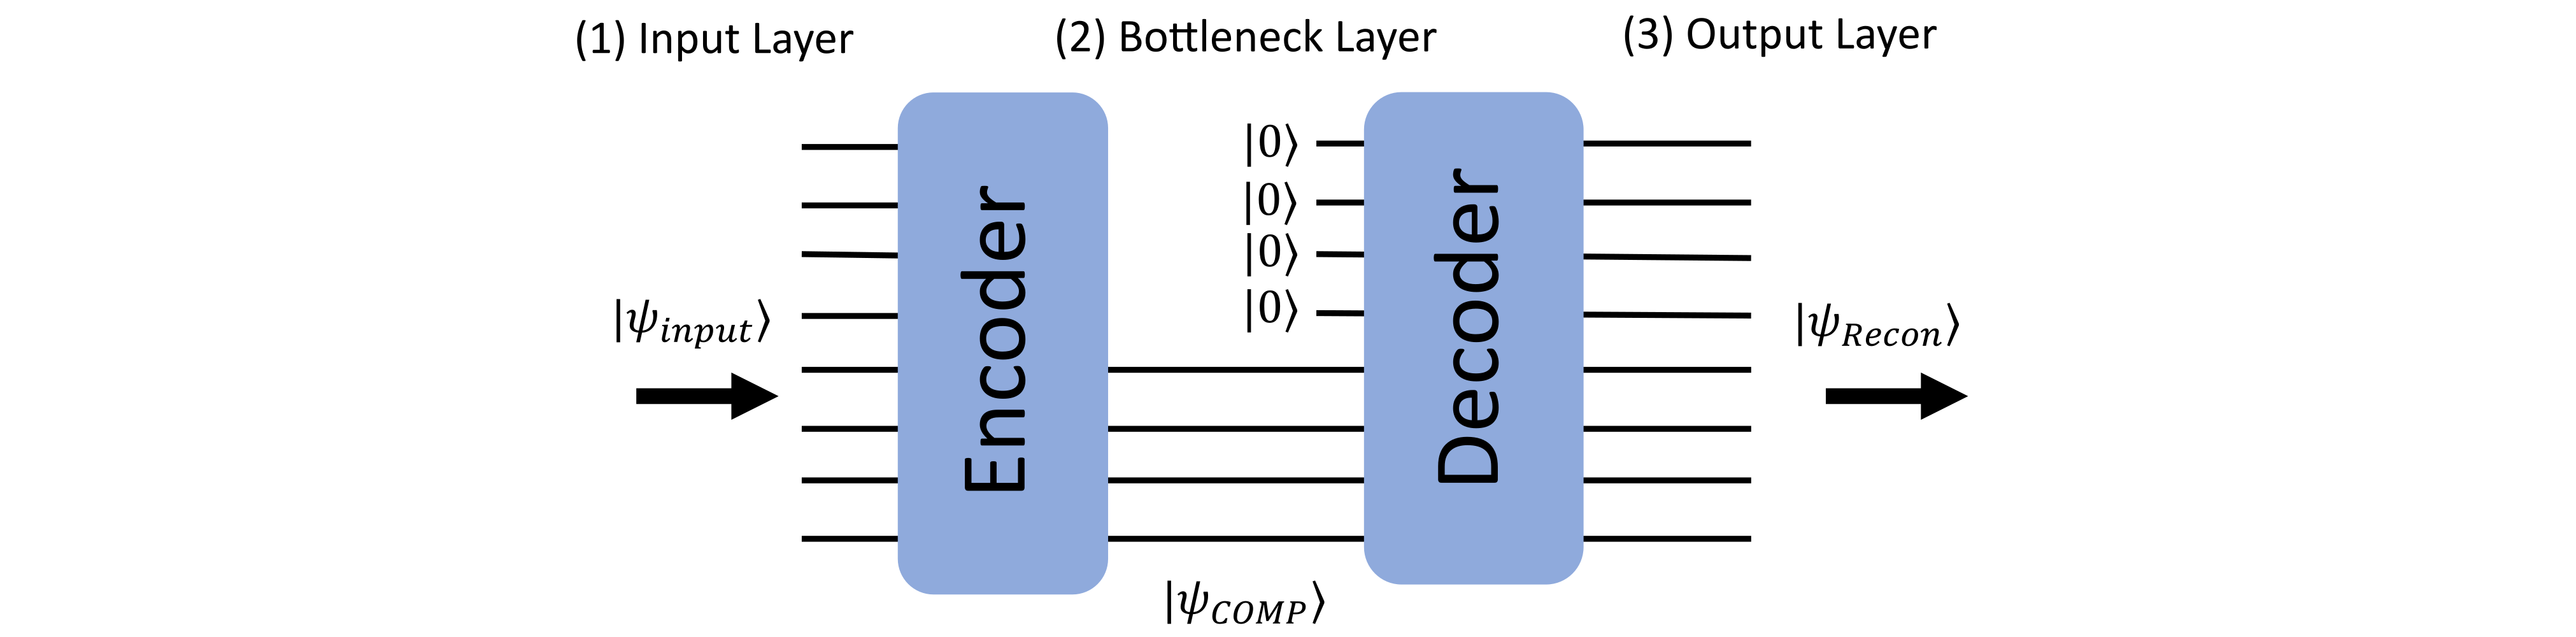

*그림 2: 양자 오토인코더(Quantum Autoencoder)의 도식적 표현. 잠재 공간(Latent Space)과 쓰레기 공간(Trash Space)이 나타나 있다.*

고전적 오토인코더와 마찬가지로 양자 오토인코더 회로도 세 개의 층으로 구성된다. 먼저 입력 상태 |ψ⟩(n개 큐비트 포함)를 회로에 입력한다. 그런 다음 매개변수화된 유니터리(Parameterized Unitary) 인코더를 적용하여 큐비트를 잠재 공간(Latent Space)과 쓰레기 공간(Trash Space)으로 나눈다. 마지막으로 인코더의 수반(Adjoint)을 적용하여 원래 상태를 복원하는 디코더를 구성한다.

## 3. 양자 오토인코더의 구성 요소(Components of a Quantum Autoencoder)

양자 오토인코더를 구축하기 전에, 몇 가지 중요한 점을 주의해야 한다.

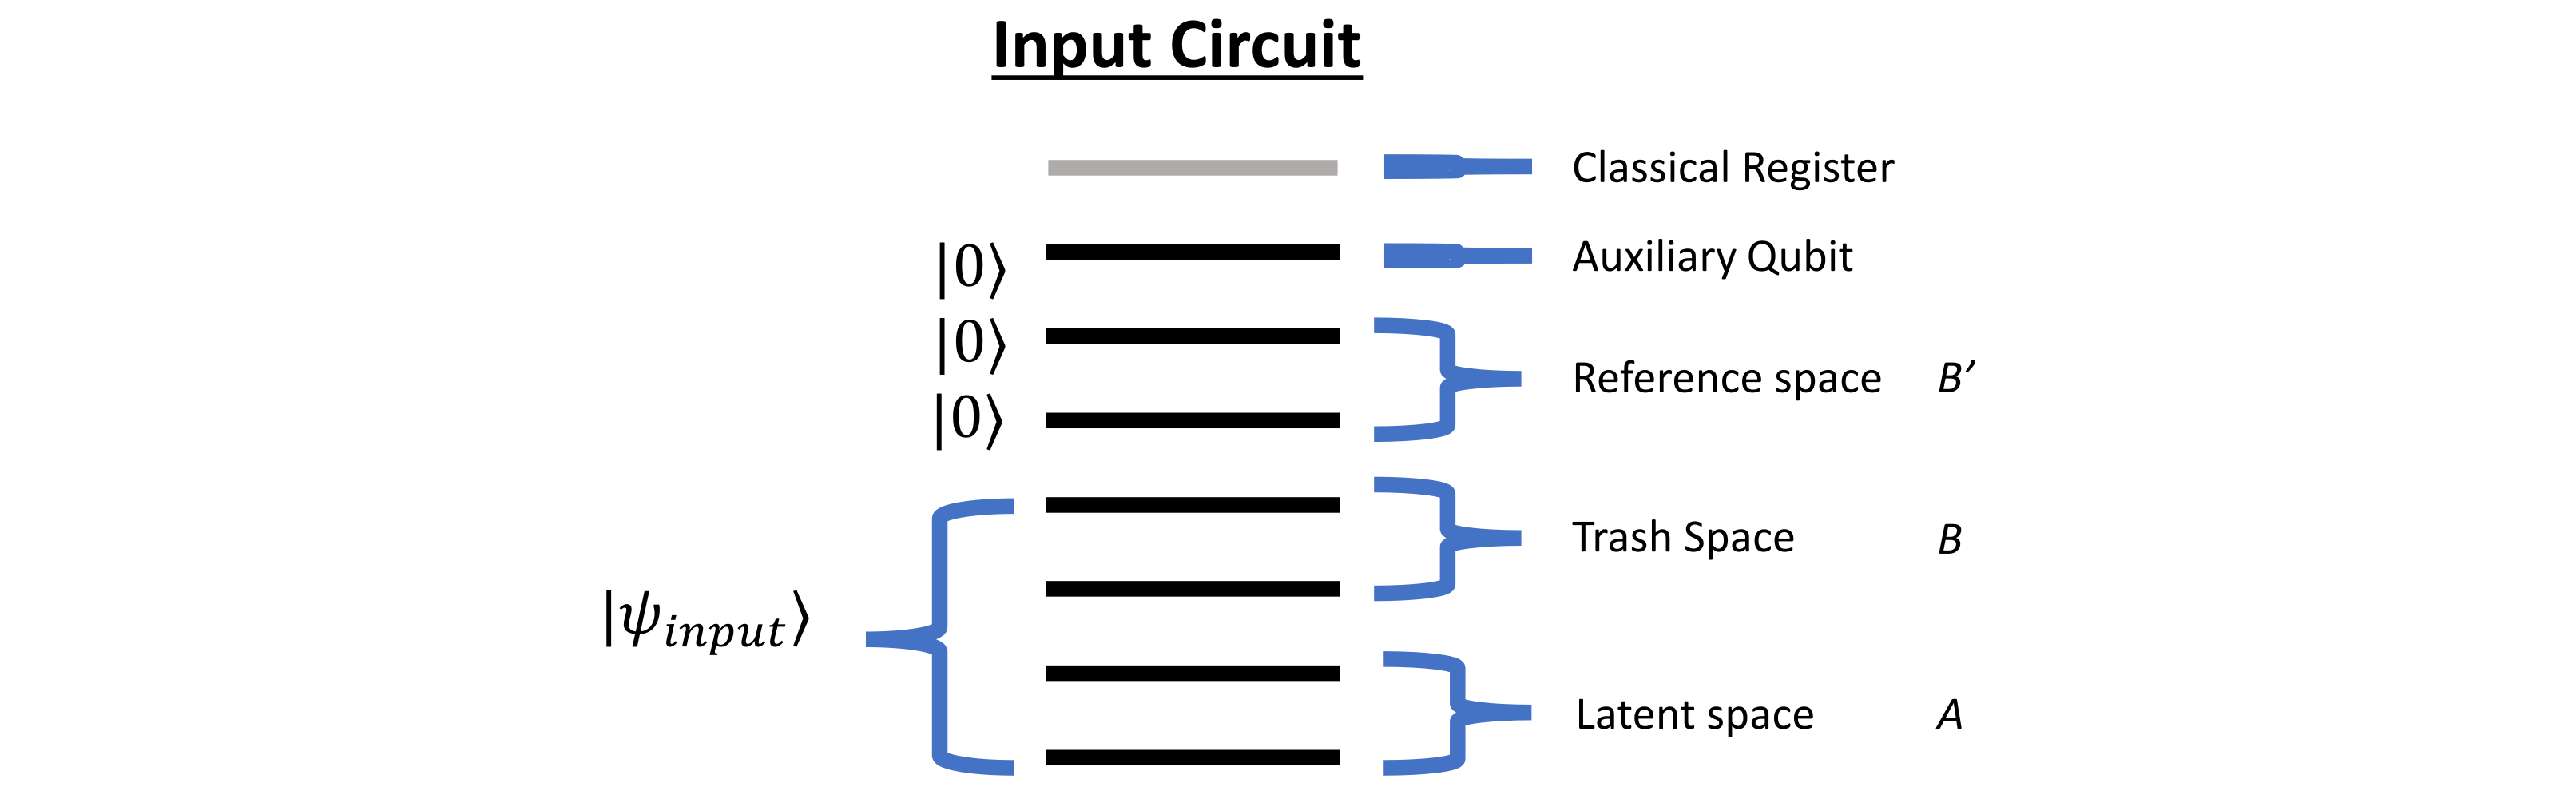

*그림 3: 양자 오토인코더 입력 상태의 도식적 표현. 잠재 큐비트(Latent Qubits)와 쓰레기 큐비트(Trash Qubits)가 |0⟩ 상태의 참조 큐비트(Reference Qubits)와 함께 나타나 있다.*

## 4. 손실 함수 선택하기(Choosing a Loss Function)

이제 우리의 비용 함수(Cost Function)를 정의하자. 이를 사용하여 양자 오토인코더를 훈련할 것이다.

### SWAP 테스트(The SWAP Test)

SWAP 테스트(SWAP Test)는 두 개의 양자 상태(Quantum State)를 비교하기 위해 일반적으로 사용되는 절차이다.

## 5. 양자 오토인코더 앤사츠 구축하기(Building the Quantum Autoencoder Ansatz)

먼저 IBM의 Qiskit을 사용하여 양자 오토인코더를 구축한다.

In [1]:
# Qiskit 라이브러리와 필요한 모듈들을 임포트한다
import json
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import ClassicalRegister, QuantumRegister
from qiskit import QuantumCircuit
from qiskit.circuit.library import real_amplitudes
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.quantum_info import Statevector
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.utils import algorithm_globals

from qiskit_machine_learning.circuit.library import raw_feature_vector
from qiskit_machine_learning.neural_networks import SamplerQNN

algorithm_globals.random_seed = 42
sampler = Sampler()

우리는 양자 오토인코더를 위한 매개변수화된 앤사츠(Parametrized Ansatz)를 정의함으로써 시작한다.

In [2]:
# 양자 오토인코더를 위한 매개변수화된 앤사츠를 정의한다
def ansatz(num_qubits):
    return real_amplitudes(num_qubits, reps=5)

이 앤사츠를 5개의 큐비트(Qubit)로 그려서 어떻게 보이는지 보자.

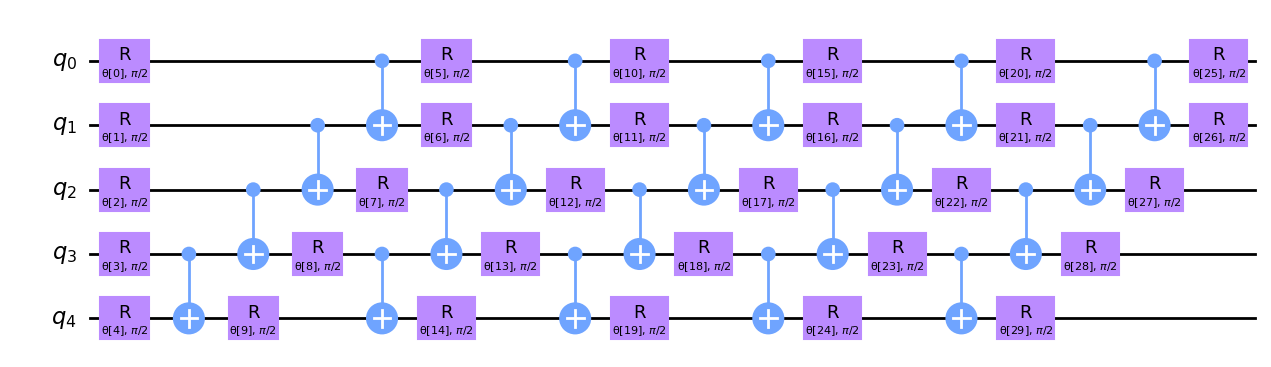

In [3]:
# 5개의 큐비트로 앤사츠를 그린다
num_qubits = 5
circ = ansatz(num_qubits)
circ.decompose().draw(output="mpl", style="clifford")

이제 우리가 압축하려는 상태에 이 인코더(Encoder)를 적용한다.

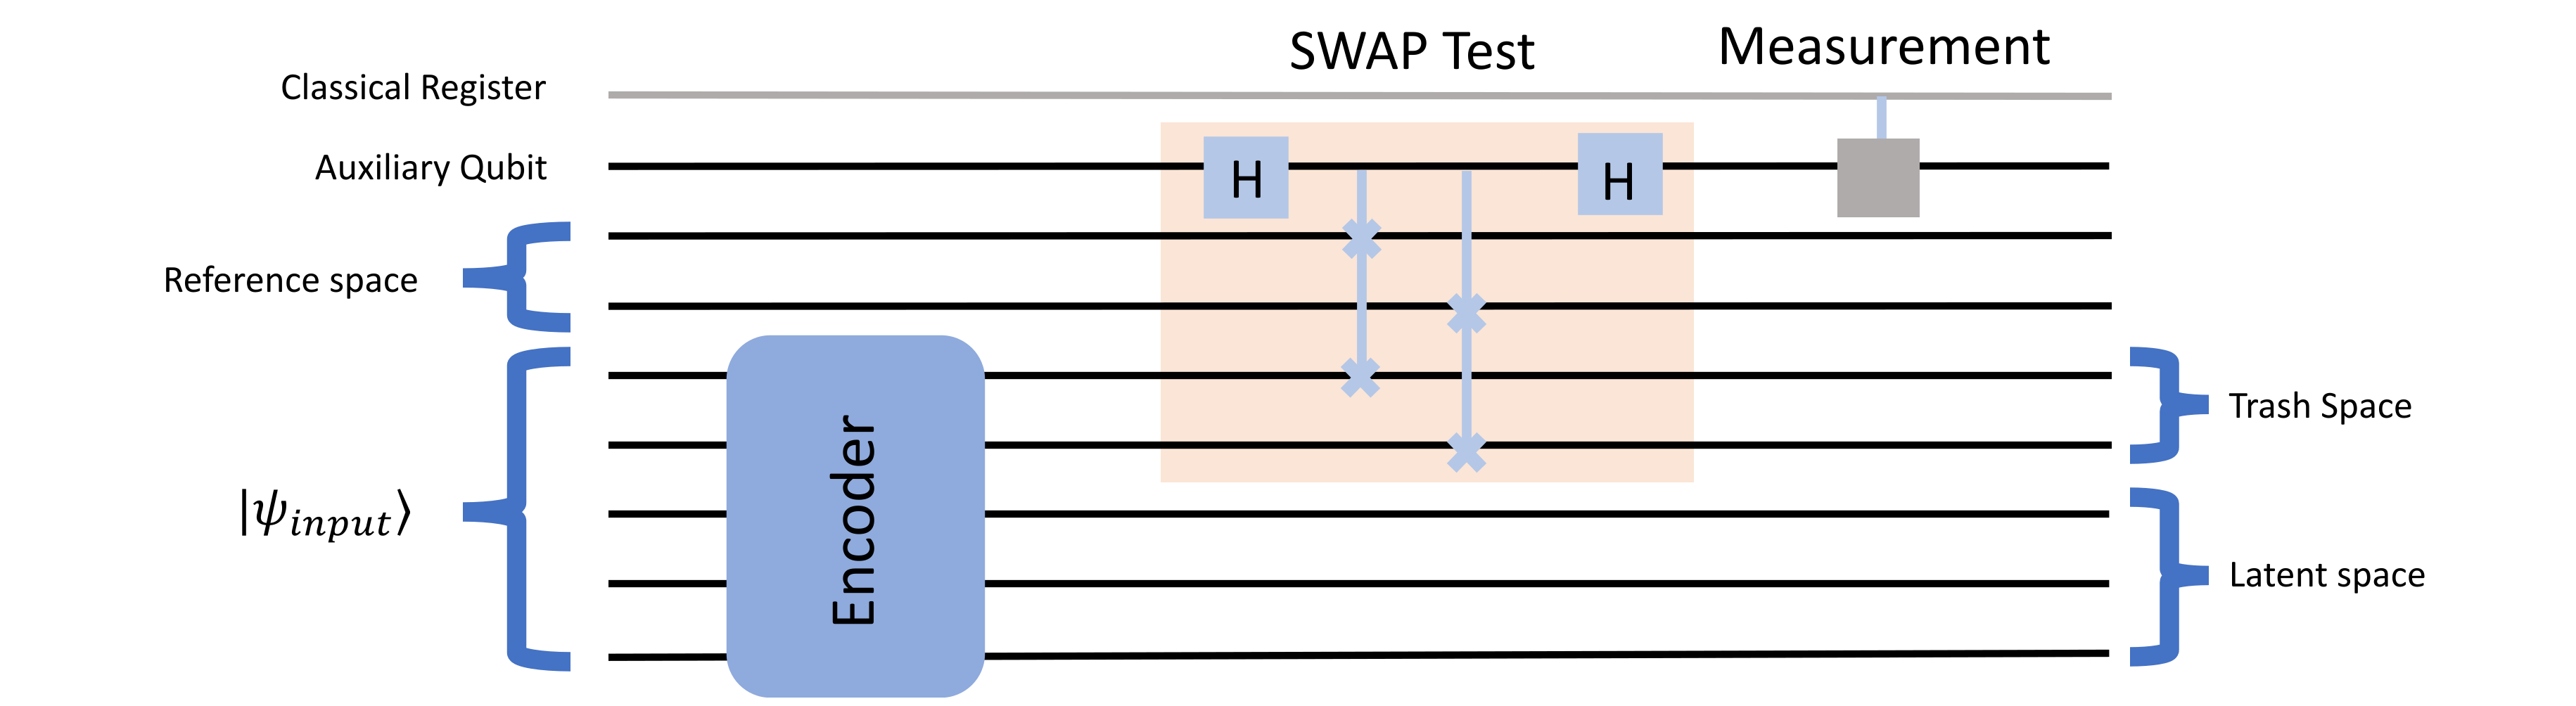

*그림 4: 훈련 과정에서의 양자 오토인코더 예시. 스왑 테스트(SWAP Test)를 사용하여 훈련 상태와 참조 상태 간의 피델리티(Fidelity)를 측정한다.*

그림 4: 훈련 단계 동안 양자 오토인코더의 예시

아래에서 위의 회로 구성을 구현하는 함수를 정의한다.

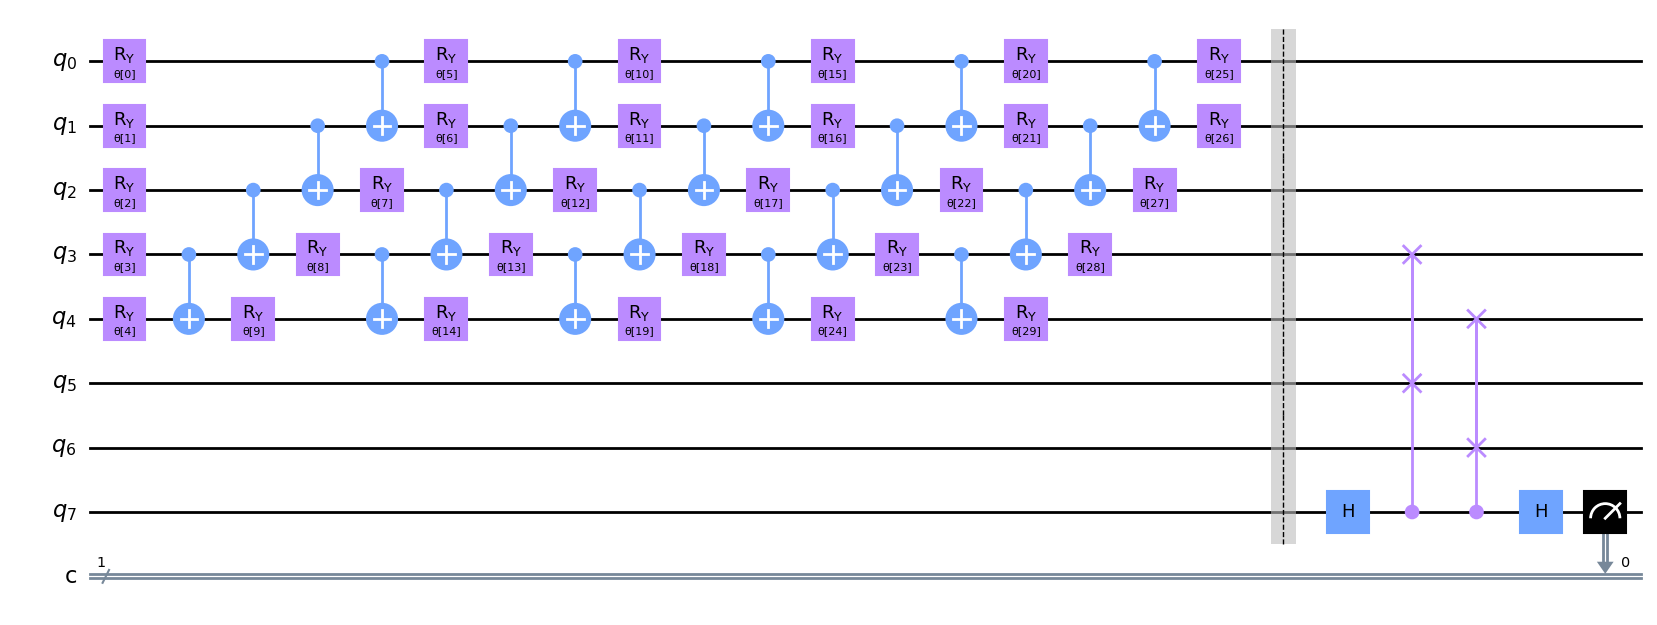

In [4]:
# 양자 오토인코더 회로를 구성하는 함수를 정의한다
def auto_encoder_circuit(num_latent, num_trash):
    qr = QuantumRegister(num_latent + 2 * num_trash + 1, "q")
    cr = ClassicalRegister(1, "c")
    circuit = QuantumCircuit(qr, cr)
    circuit.compose(ansatz(num_latent + num_trash), range(0, num_latent + num_trash), inplace=True)
    circuit.barrier()
    auxiliary_qubit = num_latent + 2 * num_trash
    # swap test
    circuit.h(auxiliary_qubit)
    for i in range(num_trash):
        circuit.cswap(auxiliary_qubit, num_latent + i, num_latent + num_trash + i)

    circuit.h(auxiliary_qubit)
    circuit.measure(auxiliary_qubit, cr[0])
    return circuit


num_latent = 3
num_trash = 2
circuit = auto_encoder_circuit(num_latent, num_trash)
circuit.draw(output="mpl", style="clifford")

원본 입력 상태를 복원하기 위해, 우리는 디코더(Decoder)를 인코더 후에 적용해야 한다.

## 6. 간단한 예: 도메인 월 오토인코더(A Simple Example: The Domain Wall Autoencoder)

먼저 도메인 월(Domain Wall)이라고 알려진 간단한 상태의 예를 시작하자.

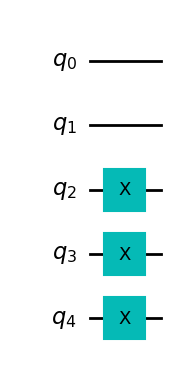

In [5]:
# 도메인 월 상태를 생성하는 함수를 정의한다
def domain_wall(circuit, a, b):
    # Here we place the Domain Wall to qubits a - b in our circuit
    for i in np.arange(int(b / 2), int(b)):
        circuit.x(i)
    return circuit


domain_wall_circuit = domain_wall(QuantumCircuit(5), 0, 5)
domain_wall_circuit.draw("mpl", style="clifford")

이제 이 상태를 5큐비트에서 3큐비트로 압축하기 위해 오토인코더를 훈련하자.

우리는 손실 함수에서 사용될 회로를 생성한다.

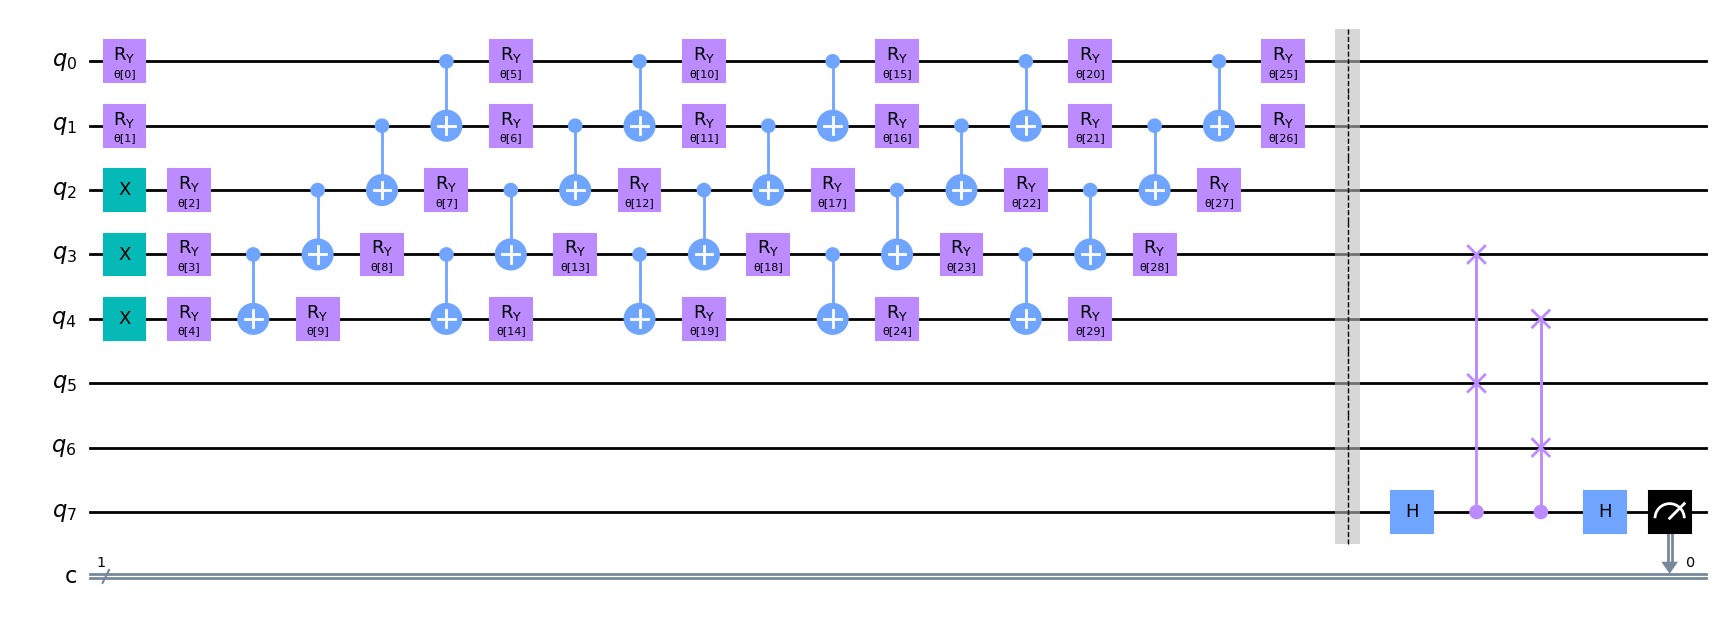

In [6]:
# 양자 오토인코더 회로를 생성한다
ae = auto_encoder_circuit(num_latent, num_trash)
qc = QuantumCircuit(num_latent + 2 * num_trash + 1, 1)
qc = qc.compose(domain_wall_circuit, range(num_latent + num_trash))
qc = qc.compose(ae)
qc.draw(output="mpl", style="clifford")

그 다음, 우리는 양자 신경망(Quantum Neural Network)을 생성하고 회로를 전달한다.

In [7]:
# SamplerQNN을 위한 인터프리터(Interpret)를 정의한다
# Here we define our interpret for our SamplerQNN
def identity_interpret(x):
    return x


qnn = SamplerQNN(
    circuit=qc,
    input_params=[],
    weight_params=ae.parameters,
    interpret=identity_interpret,
    output_shape=2,
    sampler=sampler,
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


다음으로 우리의 비용 함수를 생성한다. 이전에 설명한 것처럼, 우리는 SWAP 테스트를 사용하여 압축된 상태와 원본 상태 사이의 충실도(Fidelity)를 측정한다.

In [8]:
# 도메인 월 상태를 위한 비용 함수를 정의한다
def cost_func_domain(params_values):
    probabilities = qnn.forward([], params_values)
    # we pick a probability of getting 1 as the output of the network
    cost = np.sum(probabilities[:, 1])

    # plotting part
    clear_output(wait=True)
    objective_func_vals.append(cost)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()
    return cost

이제 양자 오토인코더를 훈련하여 도메인 월 상태의 차원을 줄인다.

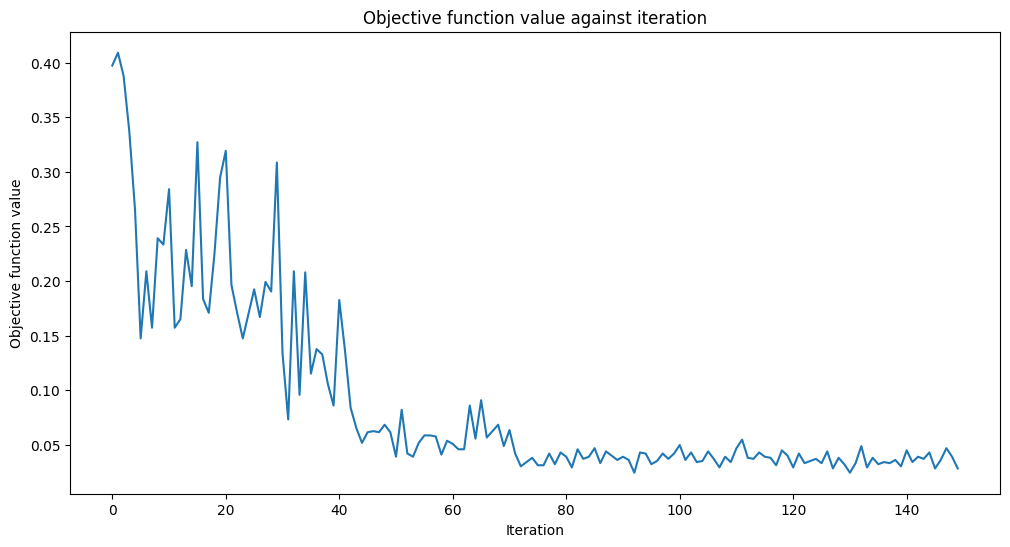

Fit in 6.10 seconds


In [9]:
# COBYLA 옵티마이저를 사용하여 양자 오토인코더를 훈련한다
opt = COBYLA(maxiter=150)
initial_point = algorithm_globals.random.random(ae.num_parameters)

objective_func_vals = []
# make the plot nicer
plt.rcParams["figure.figsize"] = (12, 6)

start = time.time()
opt_result = opt.minimize(cost_func_domain, initial_point)
elapsed = time.time() - start

print(f"Fit in {elapsed:0.2f} seconds")

수렴한 것 같다! 양자 오토인코더를 훈련한 후, 이제 압축된 상태가 원본 상태와 얼마나 유사한지 확인하자.

먼저 도메인 월 상태를 사용하여 회로를 적용하자.

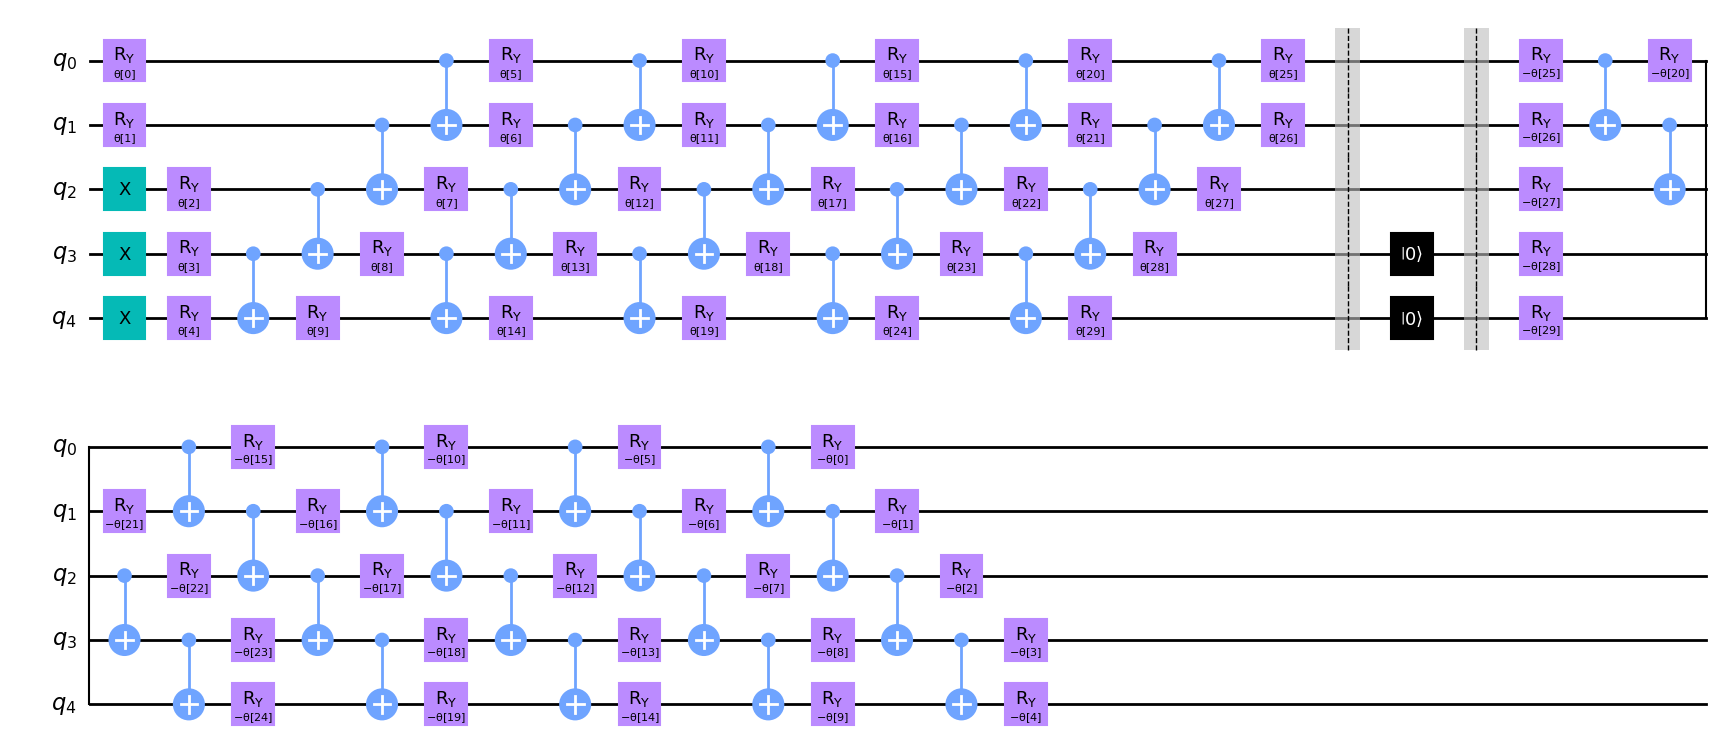

In [10]:
# 테스트를 위한 양자 회로를 구성한다
test_qc = QuantumCircuit(num_latent + num_trash)
test_qc = test_qc.compose(domain_wall_circuit)
ansatz_qc = ansatz(num_latent + num_trash)
test_qc = test_qc.compose(ansatz_qc)
test_qc.barrier()
test_qc.reset(4)
test_qc.reset(3)
test_qc.barrier()
test_qc = test_qc.compose(ansatz_qc.inverse())

test_qc.draw(output="mpl", style="clifford")

이제 훈련에서 얻은 매개변수 값을 할당한다.

In [11]:
# 훈련에서 얻은 최적 매개변수를 할당한다
test_qc = test_qc.assign_parameters(opt_result.x)

이제 도메인 월 상태와 복원된 상태의 상태 벡터(Statevector)를 얻자.

In [12]:
# 도메인 월 상태의 상태 벡터(Statevector)를 얻고 충실도(Fidelity)를 계산한다
domain_wall_state = Statevector(domain_wall_circuit).data
output_state = Statevector(test_qc).data

fidelity = np.sqrt(np.dot(domain_wall_state.conj(), output_state) ** 2)
print("Fidelity of our Output State with our Input State: ", fidelity.real)

Fidelity of our Output State with our Input State:  0.9624002233565587


보다시피 우리의 충실도(Fidelity)가 매우 높고 우리의 오토인코더가 성공적으로 상태를 압축했다.

## 7. 디지털 압축을 위한 양자 오토인코더(A Quantum Autoencoder for Digital Compression)

또한 양자 오토인코더를 더 복잡한 상태, 예를 들어 필기 숫자(Handwritten Digits)에 적용할 수 있다.

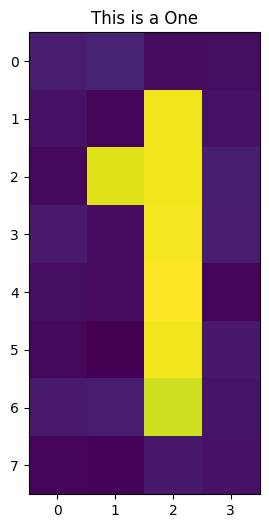

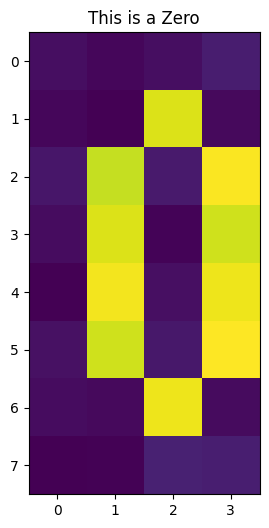

In [13]:
# 필기 숫자 데이터를 처리하기 위한 함수들을 정의한다
def zero_idx(j, i):
    # Index for zero pixels
    return [
        [i, j],
        [i - 1, j - 1],
        [i - 1, j + 1],
        [i - 2, j - 1],
        [i - 2, j + 1],
        [i - 3, j - 1],
        [i - 3, j + 1],
        [i - 4, j - 1],
        [i - 4, j + 1],
        [i - 5, j],
    ]


def one_idx(i, j):
    # Index for one pixels
    return [[i, j - 1], [i, j - 2], [i, j - 3], [i, j - 4], [i, j - 5], [i - 1, j - 4], [i, j]]


def get_dataset_digits(num, draw=True):
    # Create Dataset containing zero and one
    train_images = []
    train_labels = []
    for i in range(int(num / 2)):
        # First we introduce background noise
        empty = np.array([algorithm_globals.random.uniform(0, 0.1) for i in range(32)]).reshape(
            8, 4
        )

        # Now we insert the pixels for the one
        for i, j in one_idx(2, 6):
            empty[j][i] = algorithm_globals.random.uniform(0.9, 1)
        train_images.append(empty)
        train_labels.append(1)
        if draw:
            plt.title("This is a One")
            plt.imshow(train_images[-1])
            plt.show()

    for i in range(int(num / 2)):
        empty = np.array([algorithm_globals.random.uniform(0, 0.1) for i in range(32)]).reshape(
            8, 4
        )

        # Now we insert the pixels for the zero
        for k, j in zero_idx(2, 6):
            empty[k][j] = algorithm_globals.random.uniform(0.9, 1)

        train_images.append(empty)
        train_labels.append(0)
        if draw:
            plt.imshow(train_images[-1])
            plt.title("This is a Zero")
            plt.show()

    train_images = np.array(train_images)
    train_images = train_images.reshape(len(train_images), 32)

    for i in range(len(train_images)):
        sum_sq = np.sum(train_images[i] ** 2)
        train_images[i] = train_images[i] / np.sqrt(sum_sq)

    return train_images, train_labels


train_images, __ = get_dataset_digits(2)

이미지를 5개의 큐비트로 인코딩한 후, 우리는 모델 훈련을 시작한다.

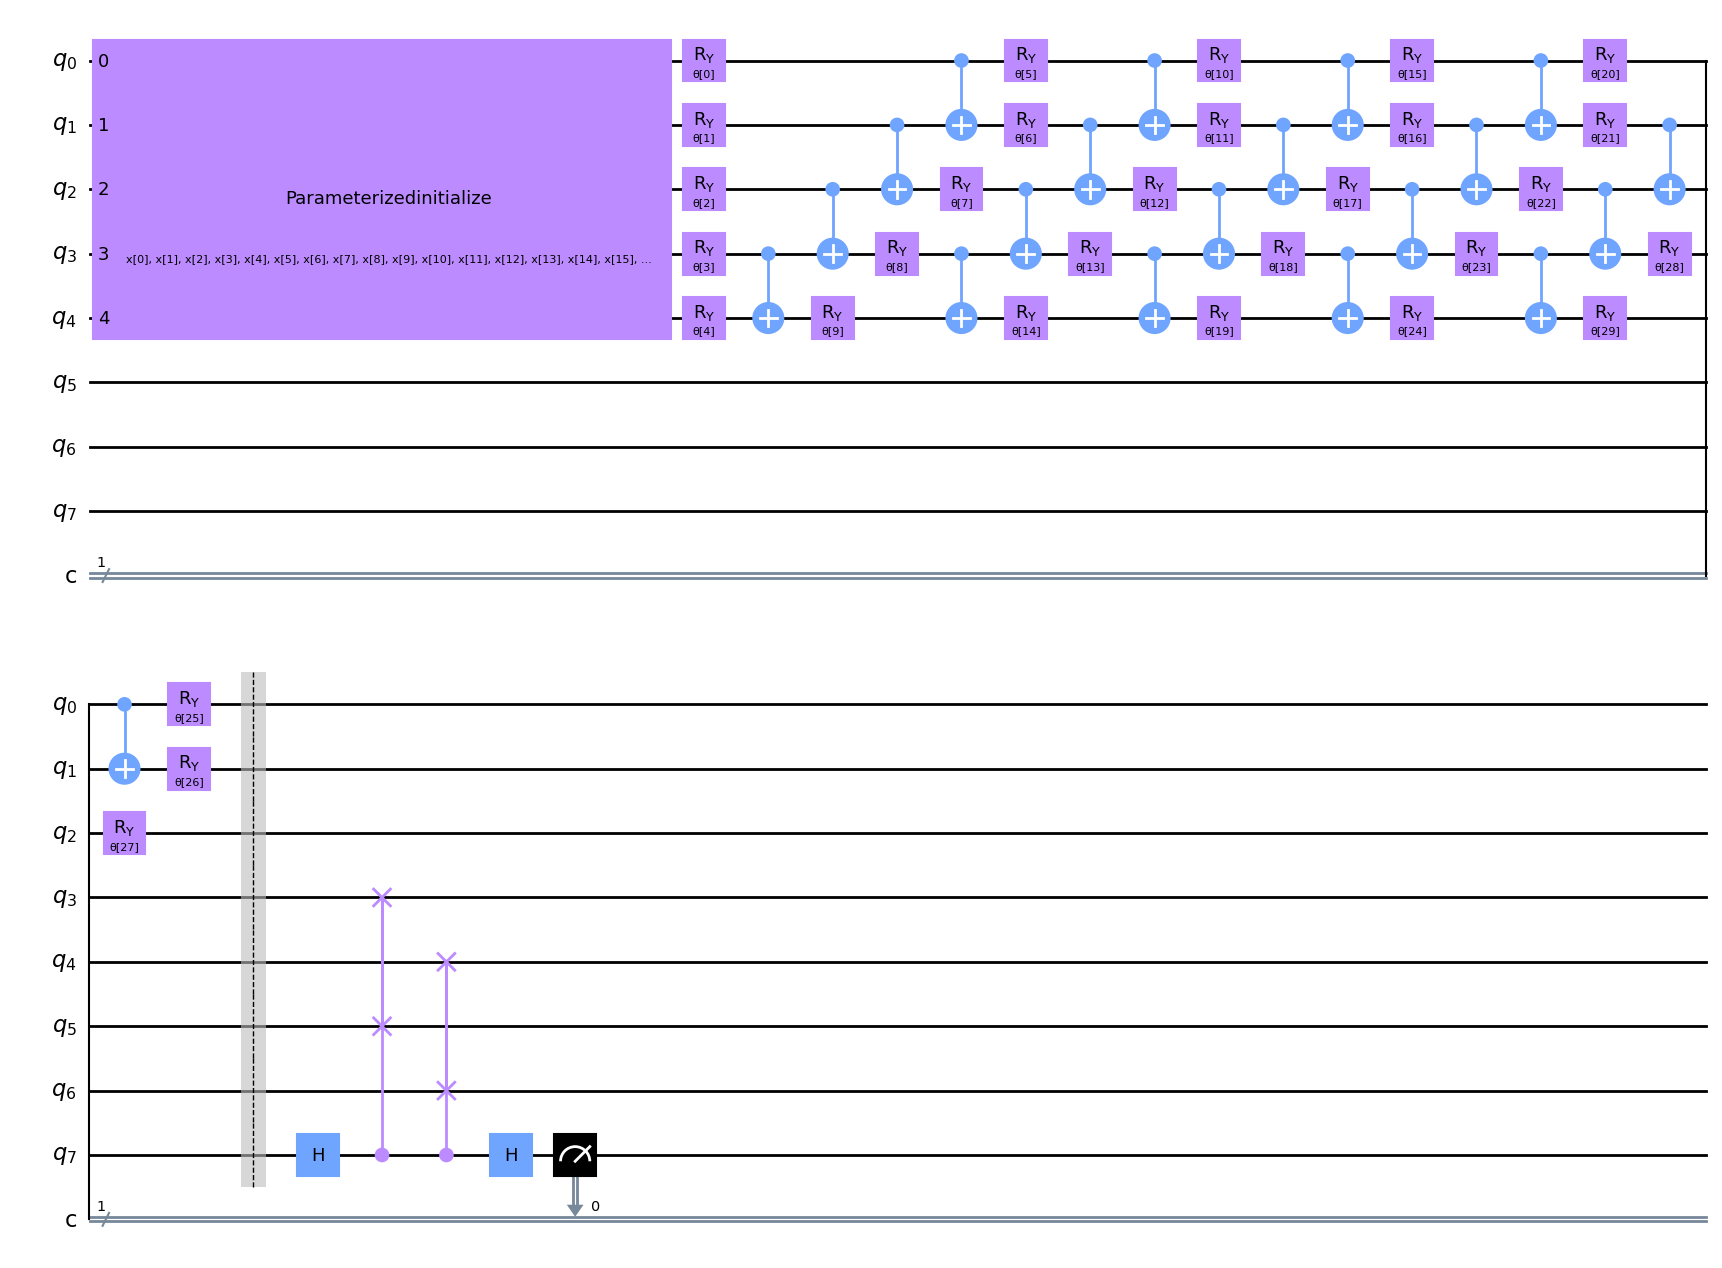

In [14]:
# 필기 숫자 압축을 위한 매개변수를 설정한다
num_latent = 3
num_trash = 2

fm = raw_feature_vector(2 ** (num_latent + num_trash))

ae = auto_encoder_circuit(num_latent, num_trash)

qc = QuantumCircuit(num_latent + 2 * num_trash + 1, 1)
qc = qc.compose(fm, range(num_latent + num_trash))
qc = qc.compose(ae)

qc.draw(output="mpl", style="clifford")

다시 한 번, 우리는 쓰레기 공간(Trash Space)의 큐비트와 보조 큐비트 사이에서 수행되는 SWAP 테스트를 볼 수 있다.

In [15]:
# 필기 숫자 압축을 위한 SamplerQNN을 정의한다
def identity_interpret(x):
    return x


qnn = SamplerQNN(
    circuit=qc,
    input_params=fm.parameters,
    weight_params=ae.parameters,
    interpret=identity_interpret,
    output_shape=2,
    sampler=sampler,
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


우리는 원래 이미지와 복원된 이미지 사이의 SWAP 테스트를 기반으로 우리의 비용 함수를 구축한다.

In [16]:
# 필기 숫자 압축을 위한 비용 함수를 정의한다
def cost_func_digits(params_values):
    probabilities = qnn.forward(train_images, params_values)
    cost = np.sum(probabilities[:, 1]) / train_images.shape[0]

    # plotting part
    clear_output(wait=True)
    objective_func_vals.append(cost)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

    return cost

모델 훈련에는 시간이 오래 걸릴 수 있으므로 우리는 이미 사전 훈련된 초기 포인트(Pre-trained Initial Point)를 제공했다.

In [17]:
# 사전 훈련된 초기 포인트(Initial Point)를 JSON 파일에서 로드한다
with open("12_qae_initial_point.json", "r") as f:
    initial_point = json.load(f)

이 비용 함수를 최소화함으로써, 우리는 최적의 매개변수를 결정할 수 있다.

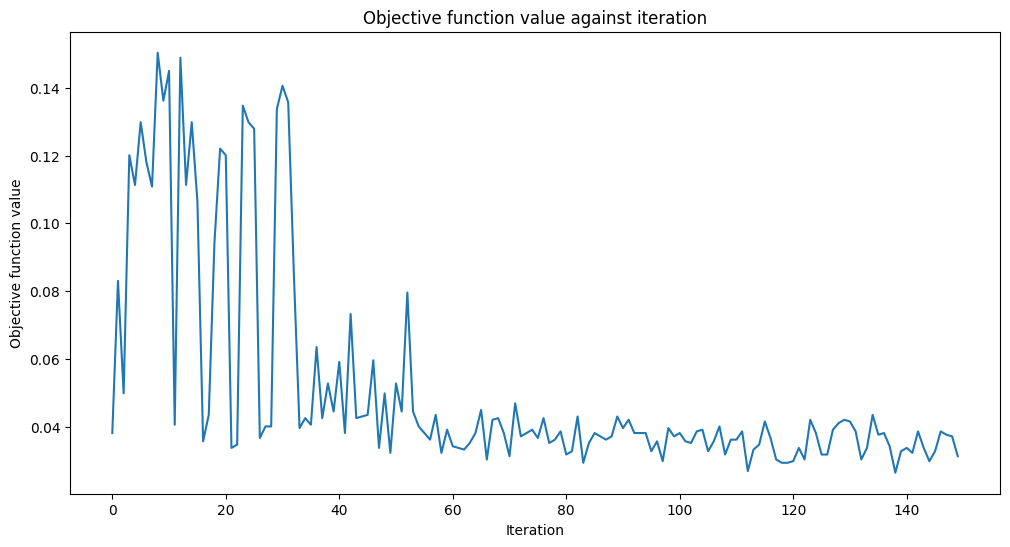

Fit in 6.45 seconds


In [18]:
# COBYLA 옵티마이저를 사용하여 필기 숫자 압축을 훈련한다
opt = COBYLA(maxiter=150)

objective_func_vals = []
# make the plot nicer
plt.rcParams["figure.figsize"] = (12, 6)

start = time.time()
opt_result = opt.minimize(fun=cost_func_digits, x0=initial_point)
elapsed = time.time() - start
print(f"Fit in {elapsed:0.2f} seconds")

수렴한 것 같다!

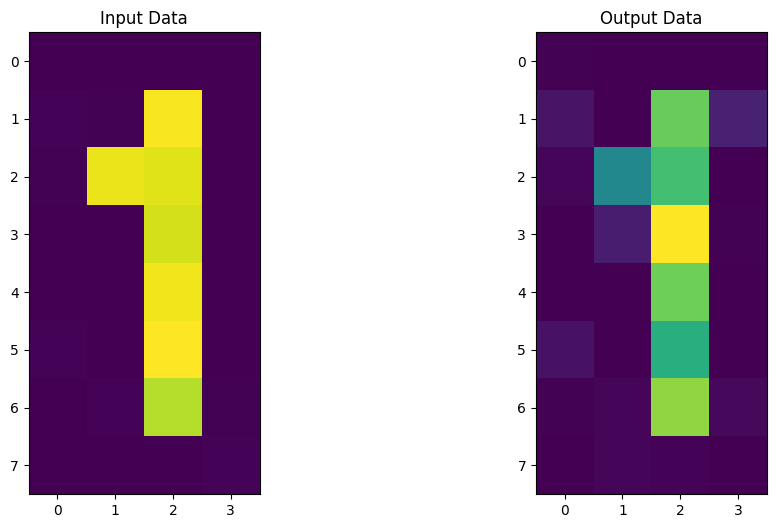

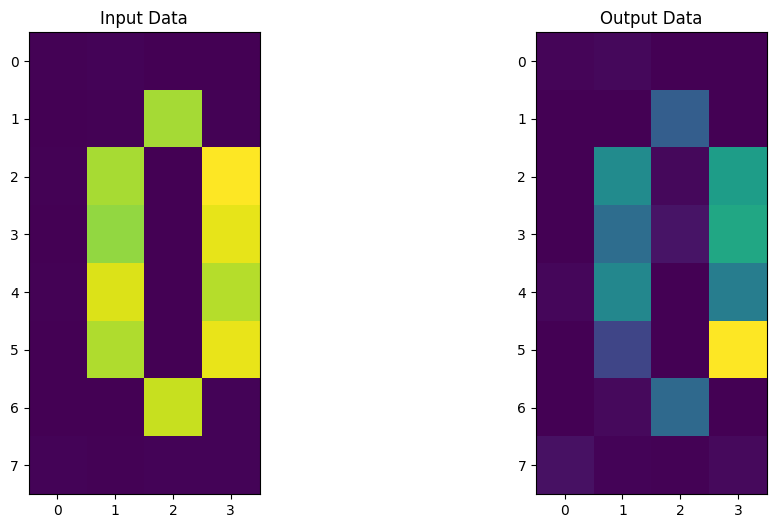

In [19]:
# 훈련된 모델을 테스트하고 결과를 시각화한다
# Test
test_qc = QuantumCircuit(num_latent + num_trash)
test_qc = test_qc.compose(fm)
ansatz_qc = ansatz(num_latent + num_trash)
test_qc = test_qc.compose(ansatz_qc)
test_qc.barrier()
test_qc.reset(4)
test_qc.reset(3)
test_qc.barrier()
test_qc = test_qc.compose(ansatz_qc.inverse())

# sample new images
test_images, test_labels = get_dataset_digits(2, draw=False)
for image, label in zip(test_images, test_labels):
    original_qc = fm.assign_parameters(image)
    original_sv = Statevector(original_qc).data
    original_sv = np.reshape(np.abs(original_sv) ** 2, (8, 4))

    param_values = np.concatenate((image, opt_result.x))
    output_qc = test_qc.assign_parameters(param_values)
    output_sv = Statevector(output_qc).data
    output_sv = np.reshape(np.abs(output_sv) ** 2, (8, 4))

    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.imshow(original_sv)
    ax1.set_title("Input Data")
    ax2.imshow(output_sv)
    ax2.set_title("Output Data")
    plt.show()

우리의 양자 오토인코더가 필기 숫자를 효과적으로 인코딩하도록 훈련될 수 있음을 보여준다.

## 8. 양자 오토인코더의 응용(Applications of a Quantum Autoencoder)

양자 오토인코더(Quantum Autoencoder)는 여러 다양한 응용 프로그램에 사용될 수 있다.

## 9. 참고자료(References)

1. 오토인코더에 대한 위키피디아 페이지: https://en.wikipedia.org/wiki/Autoencoder
2. Iten et al. (2020): "Discovering physical concepts with neural networks" Phys. Rev. Lett. 124, 010508
3. Bondesan, R., & Larocca, M. (2021). "Efficient learning of quantum noise" arXiv:2011.00814

In [20]:
# 튜토리얼 마직을 임포트한다
import tutorial_magics

%qiskit_version_table
%qiskit_copyright